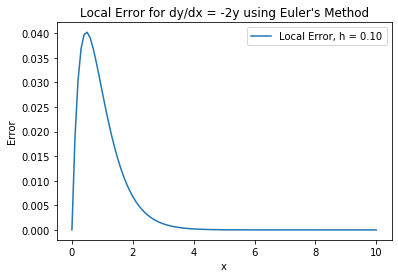

h = 0.10
Local error at each point:
[0.00000000e+00 1.87307531e-02 3.03200460e-02 3.68116361e-02
 3.97289641e-02 4.01994412e-02 3.90502119e-02 3.68817639e-02
 3.41243580e-02 3.10811602e-02 2.79611008e-02 2.49038124e-02
 2.19984766e-02 1.92979968e-02 1.68295975e-02 1.46026963e-02
 1.26147063e-02 1.08552718e-02 9.30932394e-03 7.95925305e-03
 6.78642384e-03 5.77220478e-03 4.89864227e-03 4.14887764e-03
 3.50738057e-03 2.96005381e-03 2.49424987e-03 2.09872930e-03
 1.76358241e-03 1.48012970e-03 1.24081214e-03 1.03907860e-03
 8.69275648e-04 7.26542737e-04 6.06714908e-04 5.06233773e-04
 4.22067255e-04 3.51637918e-04 2.92759559e-04 2.43581480e-04
 2.02539828e-04 1.68315330e-04 1.39796732e-04 1.16049320e-04
 9.62878964e-05 7.98536611e-05 6.61944875e-05 5.48481341e-05
 4.54279913e-05 3.76110033e-05 3.11274528e-05 2.57523371e-05
 2.12980978e-05 1.76085015e-05 1.45534969e-05 1.20248956e-05
 9.93275187e-06 8.20232949e-06 6.77156345e-06 5.58893849e-06
 4.61171681e-06 3.80445917e-06 3.13779156e-06 2.5

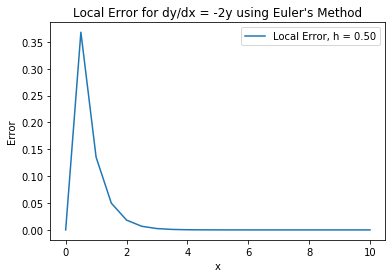

h = 0.50
Local error at each point:
[0.00000000e+00 3.67879441e-01 1.35335283e-01 4.97870684e-02
 1.83156389e-02 6.73794700e-03 2.47875218e-03 9.11881966e-04
 3.35462628e-04 1.23409804e-04 4.53999298e-05 1.67017008e-05
 6.14421235e-06 2.26032941e-06 8.31528719e-07 3.05902321e-07
 1.12535175e-07 4.13993772e-08 1.52299797e-08 5.60279644e-09
 2.06115362e-09]
Global error = 0.581976705669783


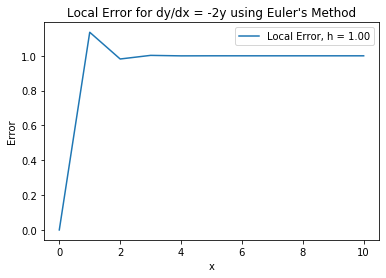

h = 1.00
Local error at each point:
[0.         1.13533528 0.98168436 1.00247875 0.99966454 1.0000454
 0.99999386 1.00000083 0.99999989 1.00000002 1.        ]
Global error = 10.119202921776422


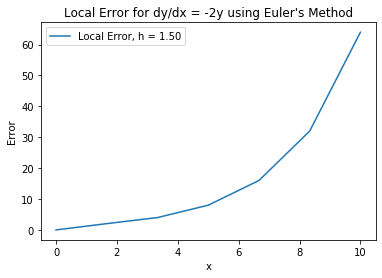

h = 1.50
Local error at each point:
[ 0.          2.03567399  3.99872737  8.0000454  15.99999838 32.00000006
 64.        ]
Global error = 126.03444519559521


In [9]:
import numpy as np
import matplotlib.pyplot as plt

h = np.array([0.1, 0.5, 1.0, 1.5])
x_start, x_end = 0, 10

def f(x, y):
    return -2 * y

def esolution(x):
    return np.exp(-2 * x)

def errors(x_values, y_values):
    y_exact = esolution(x_values)
    local_error = np.abs(y_exact - y_values)
    global_error = np.sum(local_error)
    return local_error, global_error

allx = []
ally = []

for j in range(h.size):
    num_steps = int((x_end - x_start) / h[j])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1

    for i in range(num_steps):
        
        y_values[i + 1] = y_values[i] + h[j] * f(x_values[i], y_values[i])

    allx.append(x_values)
    ally.append(y_values)


    local_error, global_error = errors(x_values, y_values)

    plt.plot(x_values, local_error, label = ("Local Error, h = " f"{h[j]:.2f}"))
    plt.xlabel('x')
    plt.ylabel('Error')
    plt.title("Local Error for dy/dx = -2y using Euler's Method")
    plt.legend()
    plt.show()

    print(f"h = {h[j]:.2f}")
    print("Local error at each point:")
    print(local_error)
    print("Global error =", global_error)